<a href="https://colab.research.google.com/github/VonManstein142/wine_classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#knn, svm, tree

from matplotlib.pylab import cast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_red = pd.read_csv('/content/winequality-red.csv', sep=';')
df_white = pd.read_csv('/content/winequality-white.csv', sep=';')

cast = {
    "fixed acidity": float,
    "volatile acidity": float,
    "citric acid": float,
    "residual sugar": float,
    "chlorides": float,
    "free sulfur dioxide": float,
    "total sulfur dioxide": float,
    "density": float,
    "pH": float,
    "sulphates": float,
    "alcohol": float,
    "quality": float
}

df_red = df_red.astype(cast)
df_white = df_white.astype(cast)

print(df_red.dtypes)
print(df_white.dtypes)

#Index(['fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'], dtype='str')
#Index(['fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'], dtype='str')

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
dtype: object
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
dtype: object


In [ ]:
df_red.to_csv('winequality-red-casted.csv', index=False)
df_white.to_csv('winequality-white-casted.csv', index=False)
print('Casted dataframes saved successfully.')

Casted dataframes saved successfully.


### Loading and Combining Datasets for Classification

In [ ]:
# Load the casted datasets
df_red_casted = pd.read_csv('winequality-red-casted.csv')
df_white_casted = pd.read_csv('winequality-white-casted.csv')

# Add a 'type' column to distinguish between red and white wine
df_red_casted['type'] = 'red'
df_white_casted['type'] = 'white'

# Combine the datasets
df_combined = pd.concat([df_red_casted, df_white_casted], ignore_index=True)

print(f"Combined DataFrame shape: {df_combined.shape}")
display(df_combined.head())

Combined DataFrame shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red


### Data Preprocessing for Classification

In [ ]:
# Separate features (X) and target (y)
X = df_combined.drop('quality', axis=1) # Drop the target variable
y = df_combined['quality']

# Convert 'type' column to numerical using one-hot encoding if it exists
if 'type' in X.columns:
    X = pd.get_dummies(X, columns=['type'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

X_train shape: (5197, 12)
y_train shape: (5197,)
X_test shape: (1300, 12)
y_test shape: (1300,)
Features scaled successfully.


### Classification Models Implementation and Evaluation

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import os

# Global counter for plots and output directory
output_dir = 'output_artifacts'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plot_counter = 1

def evaluate_model(model, X_test_scaled, y_test, model_name):
    global plot_counter
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("\n")

    # Save classification report to a text file
    report_filename = os.path.join(output_dir, f"classification_report_{model_name.replace(' ', '_')}.txt")
    with open(report_filename, 'w') as f:
        f.write(f"--- {model_name} ---\n")
        f.write(f"Accuracy: {accuracy:.4f}\n")
        f.write("Classification Report:\n")
        f.write(classification_report(y_test, y_pred))
    print(f"Classification report saved to {report_filename}")

    return accuracy, report

# K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a starting point
print("Training KNN model...")
knn_model.fit(X_train_scaled, y_train)
print("KNN model trained.")
knn_accuracy, knn_report = evaluate_model(knn_model, X_test_scaled, y_test, "K-Nearest Neighbors")

# Support Vector Machine (SVM)
# Using a linear kernel for simplicity and faster computation, consider rbf for better performance but longer training
svm_model = SVC(kernel='linear', random_state=42)
print("Training SVM model...")
svm_model.fit(X_train_scaled, y_train)
print("SVM model trained.")
svm_accuracy, svm_report = evaluate_model(svm_model, X_test_scaled, y_test, "Support Vector Machine")

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
print("Training Decision Tree model...")
dt_model.fit(X_train_scaled, y_train)
print("Decision Tree model trained.")
dt_accuracy, dt_report = evaluate_model(dt_model, X_test_scaled, y_test, "Decision Tree")

Training KNN model...
KNN model trained.
--- K-Nearest Neighbors ---
Accuracy: 0.5585


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.15      0.09      0.11        43
         5.0       0.59      0.61      0.60       428
         6.0       0.57      0.62      0.60       567
         7.0       0.53      0.49      0.50       216
         8.0       0.31      0.10      0.15        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.56      1300
   macro avg       0.31      0.27      0.28      1300
weighted avg       0.54      0.56      0.55      1300



Classification report saved to output_artifacts/classification_report_K-Nearest_Neighbors.txt
Training SVM model...
SVM model trained.
--- Support Vector Machine ---
Accuracy: 0.5223
Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.00      0.00      0.00        43
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Feature Importance from Decision Tree

Plot saved to output_artifacts/plot_01_feature_importance_decision_tree.png


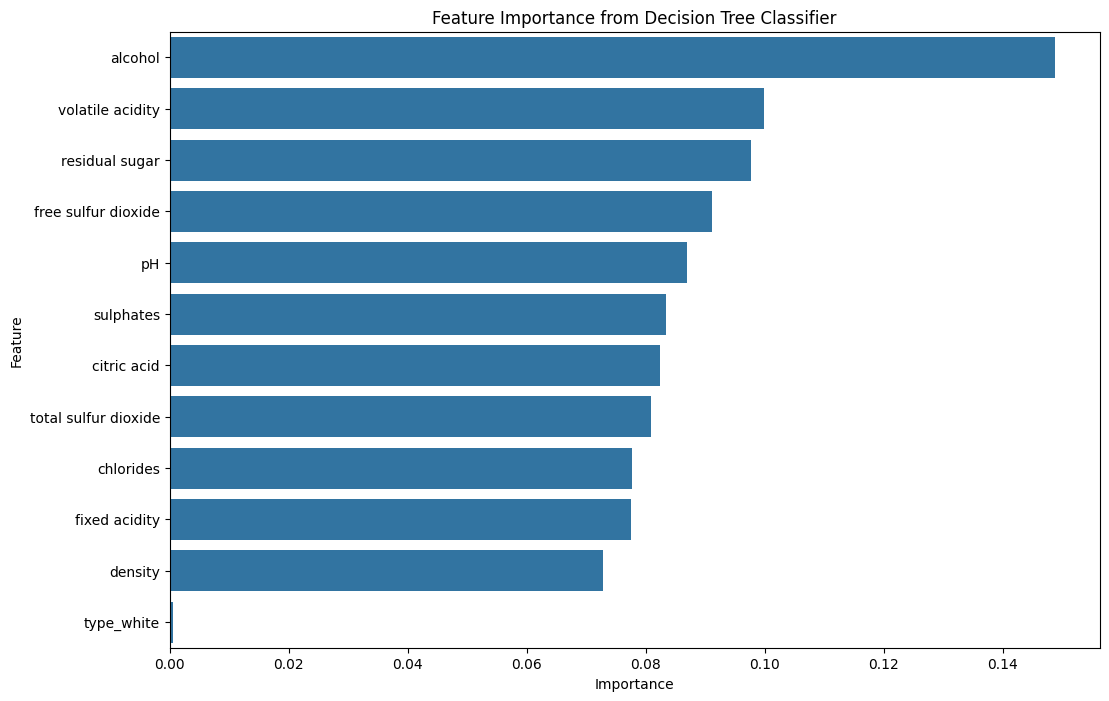

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Get feature importances from the Decision Tree model
feature_importances = dt_model.feature_importances_

# Get feature names from the original X DataFrame
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')

# Save the plot
global plot_counter
plot_filename = os.path.join(output_dir, f"plot_{plot_counter:02d}_feature_importance_decision_tree.png")
plt.savefig(plot_filename)
print(f"Plot saved to {plot_filename}")
plot_counter += 1

plt.show()

### Confusion Matrix Evaluation

Generating Confusion Matrix for K-Nearest Neighbors...
Plot saved to output_artifacts/plot_02_confusion_matrix_K-Nearest_Neighbors.png


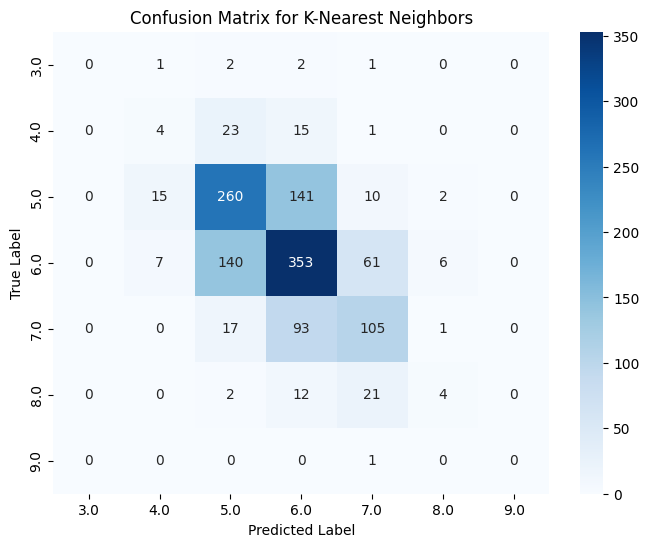

Generating Confusion Matrix for Support Vector Machine...
Plot saved to output_artifacts/plot_03_confusion_matrix_Support_Vector_Machine.png


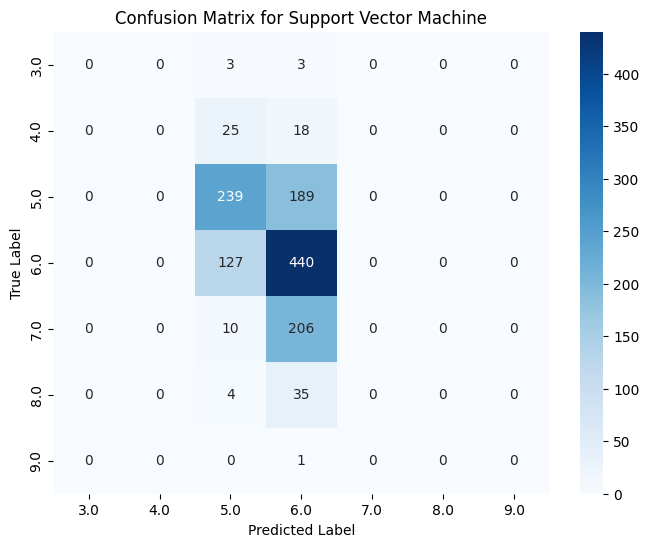

Generating Confusion Matrix for Decision Tree...
Plot saved to output_artifacts/plot_04_confusion_matrix_Decision_Tree.png


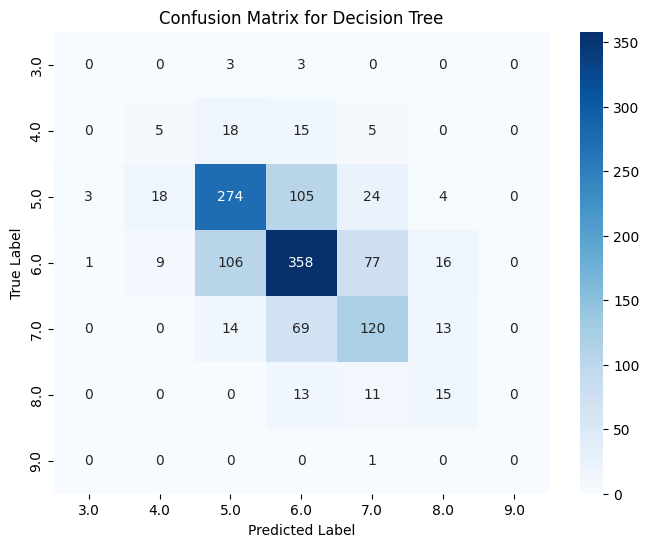

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_confusion_matrix(model, X_test_scaled, y_test, model_name):
    global plot_counter
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Save the plot
    plot_filename = os.path.join(output_dir, f"plot_{plot_counter:02d}_confusion_matrix_{model_name.replace(' ', '_')}.png")
    plt.savefig(plot_filename)
    print(f"Plot saved to {plot_filename}")
    plot_counter += 1

    plt.show()

# Confusion Matrix for KNN
print("Generating Confusion Matrix for K-Nearest Neighbors...")
plot_confusion_matrix(knn_model, X_test_scaled, y_test, "K-Nearest Neighbors")

# Confusion Matrix for SVM
print("Generating Confusion Matrix for Support Vector Machine...")
plot_confusion_matrix(svm_model, X_test_scaled, y_test, "Support Vector Machine")

# Confusion Matrix for Decision Tree
print("Generating Confusion Matrix for Decision Tree...")
plot_confusion_matrix(dt_model, X_test_scaled, y_test, "Decision Tree")

### Random Forest Model Implementation and Evaluation

### Hyperparameter Tuning for Random Forest using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
}

# Create a GridSearchCV object
# Using 'accuracy' as the scoring metric
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=param_grid,
                              cv=3, # 3-fold cross-validation
                              n_jobs=-1, # Use all available cores
                              verbose=2, # Verbose output
                              scoring='accuracy')

print("Starting GridSearchCV for Random Forest...")
grid_search_rf.fit(X_train_scaled, y_train)
print("GridSearchCV for Random Forest completed.")

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("\nBest Parameters found by GridSearchCV:")
print(grid_search_rf.best_params_)
print("\nBest Cross-validation Accuracy:")
print(f"{grid_search_rf.best_score_:.4f}")

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
GridSearchCV for Random Forest completed.

Best Parameters found by GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-validation Accuracy:
0.6552


### Evaluating the Tuned Random Forest Model

Evaluating Tuned Random Forest model...
--- Tuned Random Forest ---
Accuracy: 0.6838
Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.67      0.09      0.16        43
         5.0       0.73      0.71      0.72       428
         6.0       0.65      0.78      0.71       567
         7.0       0.66      0.59      0.62       216
         8.0       1.00      0.33      0.50        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.53      0.36      0.39      1300
weighted avg       0.69      0.68      0.67      1300



Classification report saved to output_artifacts/classification_report_Tuned_Random_Forest.txt
Generating Confusion Matrix for Tuned Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Plot saved to output_artifacts/plot_05_confusion_matrix_Tuned_Random_Forest.png


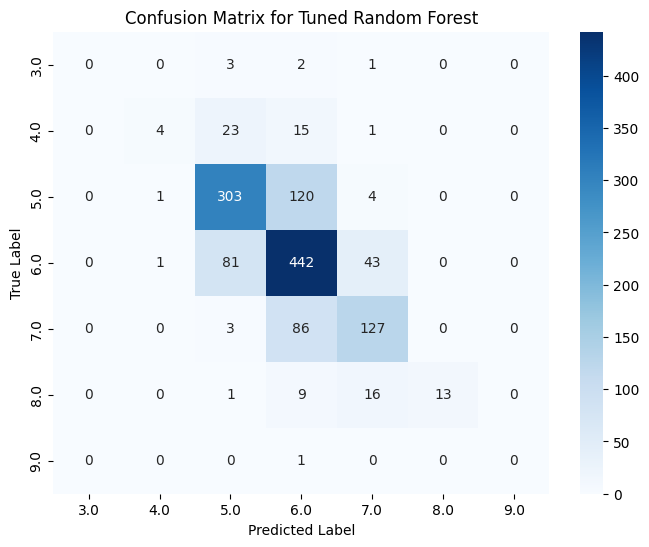

In [ ]:
# Evaluate the best Random Forest model on the test set
print("Evaluating Tuned Random Forest model...")
tuned_rf_accuracy, tuned_rf_report = evaluate_model(best_rf_model, X_test_scaled, y_test, "Tuned Random Forest")

# Generate and plot Confusion Matrix for the Tuned Random Forest model
print("Generating Confusion Matrix for Tuned Random Forest...")
plot_confusion_matrix(best_rf_model, X_test_scaled, y_test, "Tuned Random Forest")

### Hyperparameter Tuning for K-Nearest Neighbors (KNN) using GridSearchCV

Starting GridSearchCV for KNN...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
GridSearchCV for KNN completed.

Best Parameters found by GridSearchCV for KNN:
{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Best Cross-validation Accuracy for KNN:
0.6304

Evaluating Tuned KNN model...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

--- Tuned K-Nearest Neighbors ---
Accuracy: 0.6546
Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.60      0.07      0.12        43
         5.0       0.71      0.71      0.71       428
         6.0       0.65      0.71      0.67       567
         7.0       0.58      0.61      0.59       216
         8.0       0.61      0.36      0.45        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.65      1300
   macro avg       0.45      0.35      0.36      1300
weighted avg       0.65      0.65      0.64      1300



Classification report saved to output_artifacts/classification_report_Tuned_K-Nearest_Neighbors.txt
Generating Confusion Matrix for Tuned K-Nearest Neighbors...
Plot saved to output_artifacts/plot_06_confusion_matrix_Tuned_K-Nearest_Neighbors.png


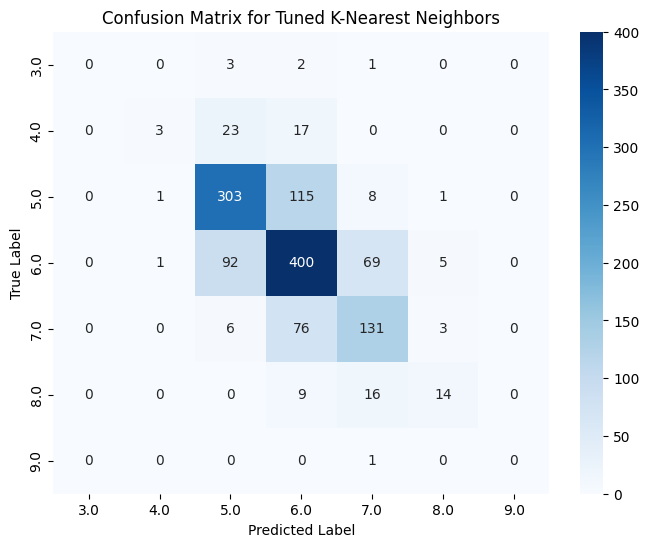

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create a GridSearchCV object for KNN
grid_search_knn = GridSearchCV(estimator=KNeighborsClassifier(),
                               param_grid=param_grid_knn,
                               cv=3,
                               n_jobs=-1,
                               verbose=2,
                               scoring='accuracy')

print("Starting GridSearchCV for KNN...")
grid_search_knn.fit(X_train_scaled, y_train)
print("GridSearchCV for KNN completed.")

# Get the best estimator
best_knn_model = grid_search_knn.best_estimator_

print("\nBest Parameters found by GridSearchCV for KNN:")
print(grid_search_knn.best_params_)
print("\nBest Cross-validation Accuracy for KNN:")
print(f"{grid_search_knn.best_score_:.4f}")

# Evaluate the best KNN model on the test set
print("\nEvaluating Tuned KNN model...")
tuned_knn_accuracy, tuned_knn_report = evaluate_model(best_knn_model, X_test_scaled, y_test, "Tuned K-Nearest Neighbors")

# Generate and plot Confusion Matrix for the Tuned KNN model
print("Generating Confusion Matrix for Tuned K-Nearest Neighbors...")
plot_confusion_matrix(best_knn_model, X_test_scaled, y_test, "Tuned K-Nearest Neighbors")

### Hyperparameter Tuning for Support Vector Machine (SVM) using GridSearchCV

Starting GridSearchCV for SVM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
GridSearchCV for SVM completed.

Best Parameters found by GridSearchCV for SVM:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Best Cross-validation Accuracy for SVM:
0.5853

Evaluating Tuned SVM model...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

--- Tuned Support Vector Machine ---
Accuracy: 0.5854
Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.35      0.14      0.20        43
         5.0       0.63      0.61      0.62       428
         6.0       0.57      0.72      0.64       567
         7.0       0.56      0.39      0.46       216
         8.0       0.43      0.08      0.13        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.36      0.28      0.29      1300
weighted avg       0.57      0.59      0.57      1300



Classification report saved to output_artifacts/classification_report_Tuned_Support_Vector_Machine.txt
Generating Confusion Matrix for Tuned Support Vector Machine...
Plot saved to output_artifacts/plot_07_confusion_matrix_Tuned_Support_Vector_Machine.png


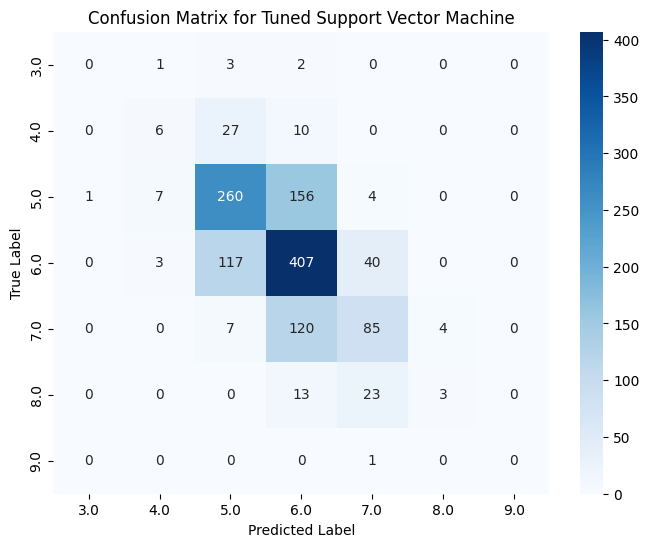

In [ ]:
from sklearn.svm import SVC

# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Create a GridSearchCV object for SVM
grid_search_svm = GridSearchCV(estimator=SVC(random_state=42),
                               param_grid=param_grid_svm,
                               cv=3,
                               n_jobs=-1,
                               verbose=2,
                               scoring='accuracy')

print("Starting GridSearchCV for SVM...")
grid_search_svm.fit(X_train_scaled, y_train)
print("GridSearchCV for SVM completed.")

# Get the best estimator
best_svm_model = grid_search_svm.best_estimator_

print("\nBest Parameters found by GridSearchCV for SVM:")
print(grid_search_svm.best_params_)
print("\nBest Cross-validation Accuracy for SVM:")
print(f"{grid_search_svm.best_score_:.4f}")

# Evaluate the best SVM model on the test set
print("\nEvaluating Tuned SVM model...")
tuned_svm_accuracy, tuned_svm_report = evaluate_model(best_svm_model, X_test_scaled, y_test, "Tuned Support Vector Machine")

# Generate and plot Confusion Matrix for the Tuned SVM model
print("Generating Confusion Matrix for Tuned Support Vector Machine...")
plot_confusion_matrix(best_svm_model, X_test_scaled, y_test, "Tuned Support Vector Machine")

### Hyperparameter Tuning for Decision Tree using GridSearchCV

Starting GridSearchCV for Decision Tree...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
GridSearchCV for Decision Tree completed.

Best Parameters found by GridSearchCV for Decision Tree:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-validation Accuracy for Decision Tree:
0.5646

Evaluating Tuned Decision Tree model...
--- Tuned Decision Tree ---
Accuracy: 0.5938
Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.16      0.12      0.13        43
         5.0       0.66      0.64      0.65       428
         6.0       0.64      0.63      0.63       567
         7.0       0.50      0.56      0.53       216
         8.0       0.31      0.38      0.34        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.32      0.33      0.33      13

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Plot saved to output_artifacts/plot_08_confusion_matrix_Tuned_Decision_Tree.png


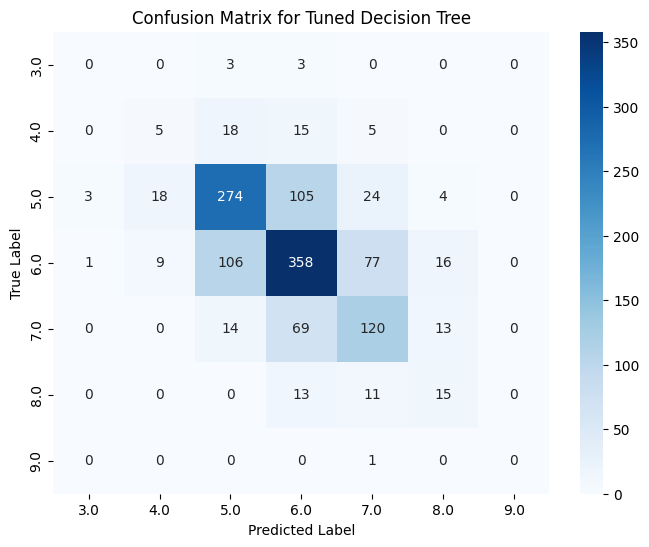

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Create a GridSearchCV object for Decision Tree
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                              param_grid=param_grid_dt,
                              cv=3,
                              n_jobs=-1,
                              verbose=2,
                              scoring='accuracy')

print("Starting GridSearchCV for Decision Tree...")
grid_search_dt.fit(X_train_scaled, y_train)
print("GridSearchCV for Decision Tree completed.")

# Get the best estimator
best_dt_model = grid_search_dt.best_estimator_

print("\nBest Parameters found by GridSearchCV for Decision Tree:")
print(grid_search_dt.best_params_)
print("\nBest Cross-validation Accuracy for Decision Tree:")
print(f"{grid_search_dt.best_score_:.4f}")

# Evaluate the best Decision Tree model on the test set
print("\nEvaluating Tuned Decision Tree model...")
tuned_dt_accuracy, tuned_dt_report = evaluate_model(best_dt_model, X_test_scaled, y_test, "Tuned Decision Tree")

# Generate and plot Confusion Matrix for the Tuned Decision Tree model
print("Generating Confusion Matrix for Tuned Decision Tree...")
plot_confusion_matrix(best_dt_model, X_test_scaled, y_test, "Tuned Decision Tree")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
print("Training Random Forest model...")
rf_model.fit(X_train_scaled, y_train)
print("Random Forest model trained.")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")

Training Random Forest model...
Random Forest model trained.
--- Random Forest ---
Accuracy: 0.6908
Classification Report:
               precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         6
         4.0       0.57      0.09      0.16        43
         5.0       0.74      0.72      0.73       428
         6.0       0.67      0.79      0.72       567
         7.0       0.66      0.58      0.62       216
         8.0       0.93      0.36      0.52        39
         9.0       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.51      0.36      0.39      1300
weighted avg       0.69      0.69      0.68      1300





/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Generating Confusion Matrix for Random Forest...


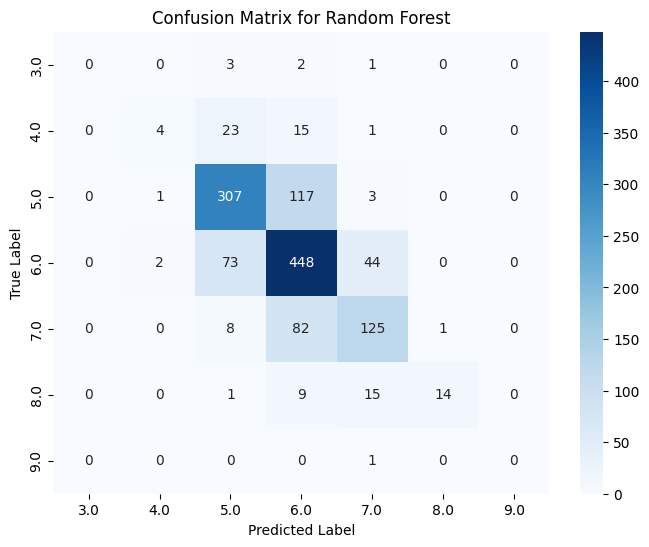

In [ ]:
print("Generating Confusion Matrix for Random Forest...")
plot_confusion_matrix(rf_model, X_test_scaled, y_test, "Random Forest")

### Comparison with Decision Tree

After running the Random Forest model, we can compare its performance against the Decision Tree:

*   **Random Forest** typically outperforms a single Decision Tree because it builds multiple decision trees and merges them to get a more accurate and stable prediction. This ensemble approach reduces overfitting, which can be a problem for individual decision trees.
*   We will observe if the **accuracy** improves and how the **classification report** changes, especially for the minority classes.
*   The **confusion matrix** for Random Forest should ideally show a more balanced distribution of predictions and better recall/precision for classes where the Decision Tree struggled.